In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import tileblockers.phase_diagram as phase_diagram

%load_ext autoreload
%autoreload 2

plt.style.use("default.mplstyle")

<frozen importlib._bootstrap>:491: RuntimeWarning: The global interpreter lock (GIL) has been enabled to load module 'polars.polars', which has not declared that it can run safely without the GIL. To override this behavior and keep the GIL disabled (at your own risk), run with PYTHON_GIL=0 or -Xgil=0.


Some caveats:

- The `ax.set_yscale` and `ax.set_xscale` functions silently change the axis label formatting.

Set y axis to nM


Text(0.5, 1.0, '2.5 µM blockers')

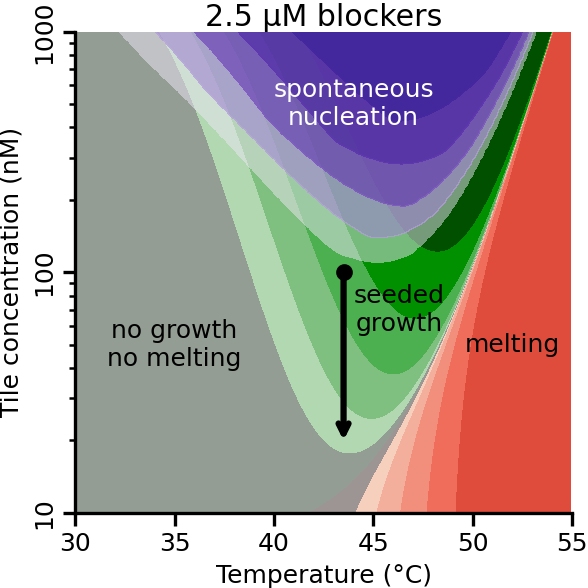

In [2]:
fig, ax = plt.subplots(figsize=(2, 2))

mult_at_100nM = 25

df = phase_diagram.value_df(np.arange(30, 55, 0.1), np.logspace(1, 3, 50) * 1e-9, 
    blocker_concs=mult_at_100nM*100e-9)
phase_diagram.draw_phase_diagram(
    phase_diagram.theory_calcs(df),
    "temperature",
    "tile_conc",
    ax=ax,
)

ax.annotate("no growth\nno melting", (35, 5e-8), ha="center", va="center")
ax.annotate("seeded\ngrowth", (46.3, 7e-8), ha="center", va="center")
ax.annotate("spontaneous\nnucleation", (44, 5e-7), ha="center", color="white", va="center")
ax.annotate("melting", (52, 5e-8), ha="center", va="center")
phase_diagram.draw_arrows(ax, [(43.5, 1e-7), (43.5, 2e-8)], lw=1.5)

# ax.set_yscale("log")
ax.set_xlim(30, 55)
ax.set_ylim(1e-8, 1e-6)
ax.set_title("2.5 µM blockers")




Set y axis to nM


Text(0.5, 1.0, '1.0 µM blockers')

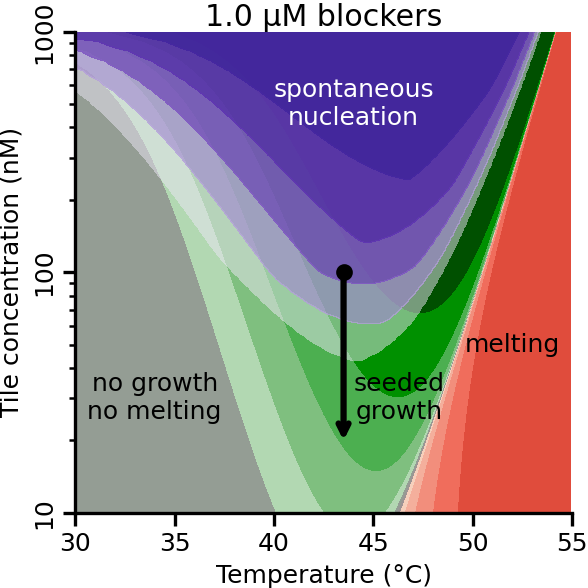

In [3]:
fig, ax = plt.subplots(figsize=(2, 2))

mult_at_100nM = 10

df = phase_diagram.value_df(np.arange(30, 55, 0.1), np.logspace(1, 3, 50) * 1e-9, 
    blocker_concs=mult_at_100nM*100e-9)
phase_diagram.draw_phase_diagram(
    phase_diagram.theory_calcs(df),
    "temperature",
    "tile_conc",
    ax=ax,
)

ax.annotate("no growth\nno melting", (34, 3e-8), ha="center", va="center")
ax.annotate("seeded\ngrowth", (46.3, 3e-8), ha="center", va="center")
ax.annotate("spontaneous\nnucleation", (44, 5e-7), ha="center", color="white", va="center")
ax.annotate("melting", (52, 5e-8), ha="center", va="center")
phase_diagram.draw_arrows(ax, [(43.5, 1e-7), (43.5, 2e-8)], lw=1.5)

# ax.set_yscale("log")
ax.set_xlim(30, 55)
ax.set_ylim(1e-8, 1e-6)
ax.set_title("1.0 µM blockers")




Set y axis to nM


Text(0.5, 1.0, 'Without blockers')

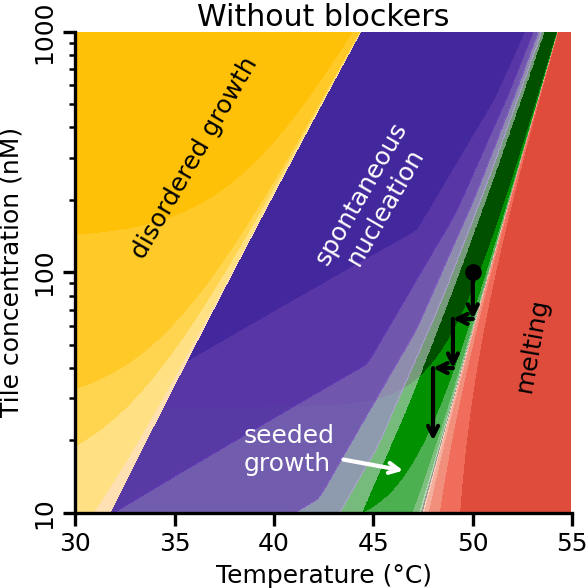

In [4]:
fig, ax = plt.subplots(figsize=(2, 2))
from matplotlib.ticker import FuncFormatter
mult_at_100nM = 0

df = phase_diagram.value_df(np.arange(30, 55, 0.1), np.logspace(1, 3, 50) * 1e-9, 
    blocker_concs=mult_at_100nM*100e-9)
phase_diagram.draw_phase_diagram(
    phase_diagram.theory_calcs(df),
    "temperature",
    "tile_conc",
    ax=ax,
)

ax.annotate("disordered growth", (36, 3e-7), ha="center", va="center", rotation=60)
ax.annotate("seeded\ngrowth", (46.5, 1.5e-8), (38.5, 1.5e-8), arrowprops=dict(arrowstyle="->", color="white", shrinkA=0, shrinkB=0), color="white")
ax.annotate("spontaneous\nnucleation", (45, 2e-7), ha="center", color="white", va="center", rotation=60)
ax.annotate("melting", (53, 5e-8), ha="center", va="center", rotation=80)

arrow_coords = [(50, 1e-7), (50, 6.4e-8), (49.0, 6.4e-8), (49.0, 4e-8), (48.0, 4e-8), (48.0, 2e-8)]
phase_diagram.draw_arrows(ax, arrow_coords)

ax.set_xlim(30, 55)
ax.set_ylim(1e-8, 1e-6)
ax.set_title("Without blockers")


In [5]:
df

temperature,tile_conc,blocker_conc,blocker_mult
f64,f64,f64,f64
30.0,1.0000e-8,0.0,0.0
30.0,1.0985e-8,0.0,0.0
30.0,1.2068e-8,0.0,0.0
30.0,1.3257e-8,0.0,0.0
30.0,1.4563e-8,0.0,0.0
…,…,…,…
54.9,6.8665e-7,0.0,0.0
54.9,7.5431e-7,0.0,0.0
54.9,8.2864e-7,0.0,0.0


Set x axis to nM


Text(0.5, 1.0, '48°C')

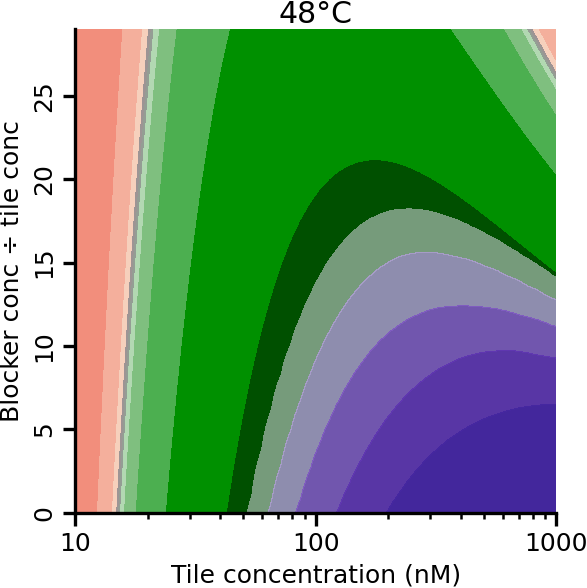

In [6]:
fig, ax = plt.subplots(figsize=(2, 2))


df = phase_diagram.value_df(48, np.logspace(1, 3, 50) * 1e-9, 
    blocker_mults=np.linspace(0, 29, 50))
phase_diagram.draw_phase_diagram(
    phase_diagram.theory_calcs(df),
    "tile_conc",
    "blocker_mult",
    ax=ax,
)

ax.annotate("no growth\nno melting", (34, 25), ha="center", va="center")
ax.annotate("seeded\ngrowth", (46.3, 25), ha="center", va="center")
ax.annotate("spontaneous\nnucleation", (44, 4), ha="center", color="white", va="center")
ax.annotate("melting", (52.5, 25), ha="center", va="center")
# phase_diagram.draw_arrows(ax, [(43.5, 1e-7), (43.5, 2e-8)], lw=1.5)

# ax.set_xlim(30, 55)
ax.set_title("48°C")




Set x axis to nM


Text(0.5, 1.0, 'Max values between 30 and 55°C')

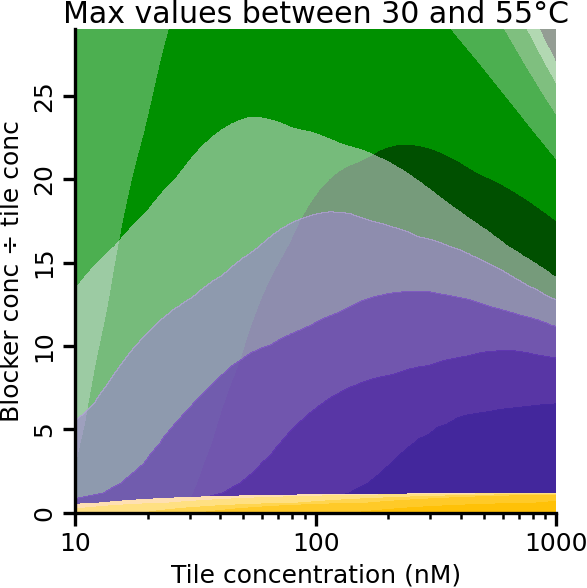

In [7]:
fig, ax = plt.subplots(figsize=(2, 2))


df = phase_diagram.value_df(np.arange(30, 55, 1), np.logspace(1, 3, 50) * 1e-9, 
    blocker_mults=np.linspace(0, 29, 50))
phase_diagram.draw_phase_diagram(
    phase_diagram.theory_calcs(df),
    "tile_conc",
    "blocker_mult",
    ax=ax,
    agg="max"
)

ax.annotate("no growth\nno melting", (34, 25), ha="center", va="center")
ax.annotate("seeded\ngrowth", (46.3, 25), ha="center", va="center")
ax.annotate("spontaneous\nnucleation", (44, 4), ha="center", color="white", va="center")
ax.annotate("melting", (52.5, 25), ha="center", va="center")
# phase_diagram.draw_arrows(ax, [(43.5, 1e-7), (43.5, 2e-8)], lw=1.5)

# ax.set_xlim(30, 55)
ax.set_title("Max values between 30 and 55°C")




Text(0.5, 1.0, '100 nM tiles')

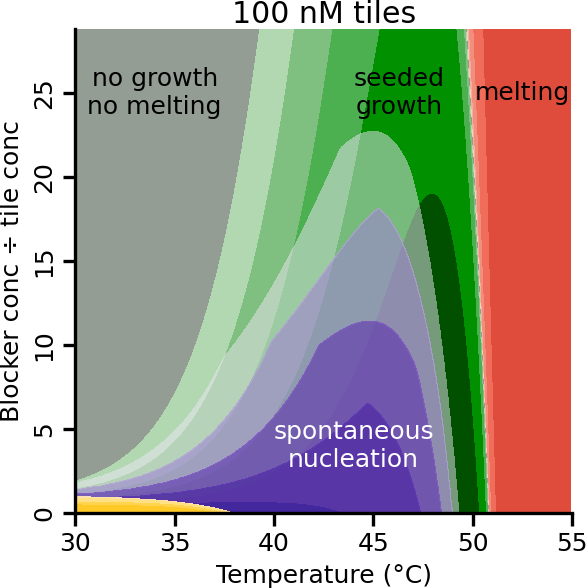

In [8]:
fig, ax = plt.subplots(figsize=(2, 2))


df = phase_diagram.value_df(np.arange(30, 55, 0.1), 100e-9, 
    blocker_mults=np.arange(0, 29, 0.2))
phase_diagram.draw_phase_diagram(
    phase_diagram.theory_calcs(df),
    "temperature",
    "blocker_mult",
    ax=ax,
)

ax.annotate("no growth\nno melting", (34, 25), ha="center", va="center")
ax.annotate("seeded\ngrowth", (46.3, 25), ha="center", va="center")
ax.annotate("spontaneous\nnucleation", (44, 4), ha="center", color="white", va="center")
ax.annotate("melting", (52.5, 25), ha="center", va="center")
# phase_diagram.draw_arrows(ax, [(43.5, 1e-7), (43.5, 2e-8)], lw=1.5)

ax.set_xlim(30, 55)
ax.set_title("100 nM tiles")




Text(0.5, 1.0, '100 nM tiles')

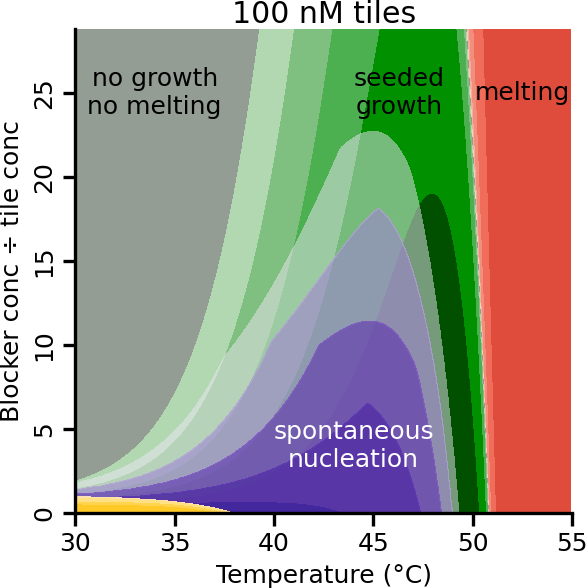

In [9]:
fig, ax = plt.subplots(figsize=(2, 2))


df = phase_diagram.value_df(np.arange(30, 55, 0.1), 100e-9, 
    blocker_mults=np.arange(0, 29, 0.2))
phase_diagram.draw_phase_diagram(
    phase_diagram.theory_calcs(df),
    "temperature",
    "blocker_mult",
    ax=ax,
)

ax.annotate("no growth\nno melting", (34, 25), ha="center", va="center")
ax.annotate("seeded\ngrowth", (46.3, 25), ha="center", va="center")
ax.annotate("spontaneous\nnucleation", (44, 4), ha="center", color="white", va="center")
ax.annotate("melting", (52.5, 25), ha="center", va="center")
# phase_diagram.draw_arrows(ax, [(43.5, 1e-7), (43.5, 2e-8)], lw=1.5)

ax.set_xlim(30, 55)
ax.set_title("100 nM tiles")




In [10]:
# from tqdm import tqdm
# from tileblockers.twelve_helix_tube import rate_per_hour_sim, run_ffs_for_system, rate_per_hour_sim_with_melting, simple_twelve_helix_system
# import polars as pl
# import numpy as np

# bmults = np.arange(0, 29, 2)
# temps = np.arange(43, 54, 1)

# rows = []
# param_combos = [(t, b) for t in temps for b in bmults]
# for t, b in tqdm(param_combos, desc="Param combos"):
#     gr = rate_per_hour_sim_with_melting(
#         t, b, n_sims=3, sys_fun=simple_twelve_helix_system
#     ) / 3600.0 / 3.5
#     rows.append({"temperature": t, "blocker_mult": b, "growth_rate": gr})

# vals = pl.DataFrame(rows).with_columns(
#     tile_conc=pl.lit(1e-7),
#     blocker_conc=pl.col("tile_conc") * pl.col("blocker_mult"),
# )


In [11]:
# from tqdm.contrib.concurrent import thread_map

# params = [(x['temperature'], x['blocker_mult']) for x in vals.iter_rows(named=True)]
# ffs_res = thread_map(lambda args: run_ffs_for_system(*args), params)
# vals = vals.with_columns(nucleation_rate=pl.Series([x[0] for x in ffs_res]), )

In [13]:
# fig, ax = plt.subplots(figsize=(2, 2))

# phase_diagram.draw_phase_diagram(vals, "temperature", "blocker_mult", include_growth1_rates=False, ax=ax,
#     include_nucleation=[1e-13, 1e-12, 1e-11, 1e-10, 1e-9, np.inf])

# ax.set_title("Sim. with 100 nM tiles")

In [15]:
# fig, ax = plt.subplots(figsize=(2, 2))

# phase_diagram.draw_phase_diagram(phase_diagram.theory_calcs(vals), "temperature", "blocker_mult", include_growth1_rates=False, ax=ax)

# ax.set_title("Theory with 100 nM tiles")

In [16]:
vals = pl.read_csv("phase_diagram_data_sims_growth.csv")

In [17]:
from pathlib import Path
import polars as pl


v = []
for f in Path("..").glob("*.csv"):
    print(f)
    df = pl.read_csv(f)
    v.append(df)

v = pl.concat(v)


../phase_diagram_data_T_3.00e+01_to_5.48e+01_n125_tile_1.00e-08_to_1.00e-06_n50_bconc_0.00e+00_to_5.00e-07_n5.csv
../phase_diagram_data_T_4.30e+01_to_5.48e+01_n60_tile_1.00e-08_to_1.00e-06_n50_bconc_2.50e-06_to_5.00e-07_n4.csv
../phase_diagram_data_T_4.50e+01_to_5.48e+01_n50_tile_1.00e-08_to_1.00e-06_n50_bconc_2.50e-06_to_5.00e-07_n4.csv


Set y axis to nM


Text(0.5, 1.0, 'Sim. with 2.5 µM blockers')

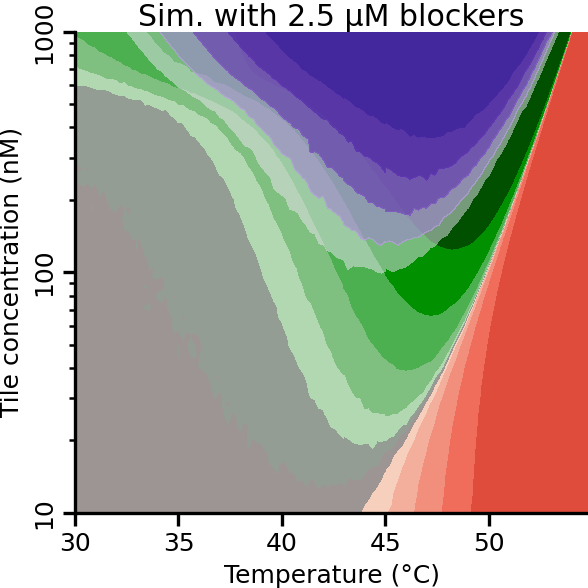

In [18]:
vals = v.filter(pl.col("blocker_conc") == 2.5e-6)

fig, ax = plt.subplots(figsize=(2, 2))

phase_diagram.draw_phase_diagram(vals, "temperature", "tile_conc", include_growth1_rates=False, ax=ax, 
    include_nucleation=[1e-13, 1e-12, 1e-11, 1e-10, 1e-9, np.inf])

ax.set_title("Sim. with 2.5 µM blockers")

Set y axis to nM


Text(0.5, 1.0, 'Sim. with no blockers')

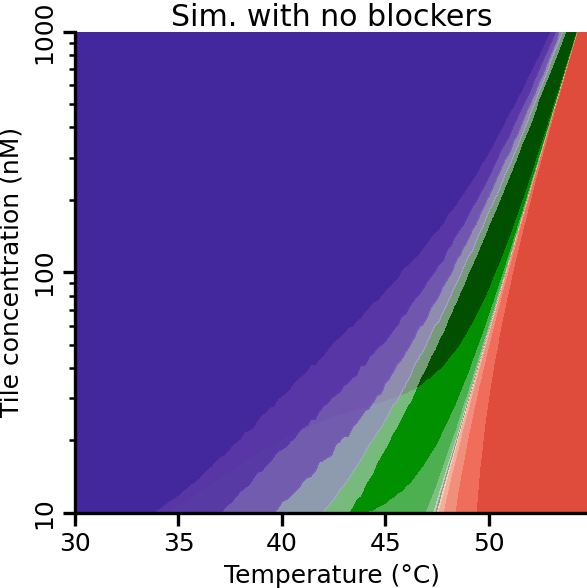

In [19]:
vals = v.filter(pl.col("blocker_conc") == 0)

fig, ax = plt.subplots(figsize=(2, 2))

phase_diagram.draw_phase_diagram(vals, "temperature", "tile_conc", include_growth1_rates=False, ax=ax, 
    include_nucleation=[1e-13, 1e-12, 1e-11, 1e-10, 1e-9, np.inf])

ax.set_title("Sim. with no blockers")

Set y axis to nM


Text(0.5, 1.0, 'Sim. with 1.0 µM blockers')

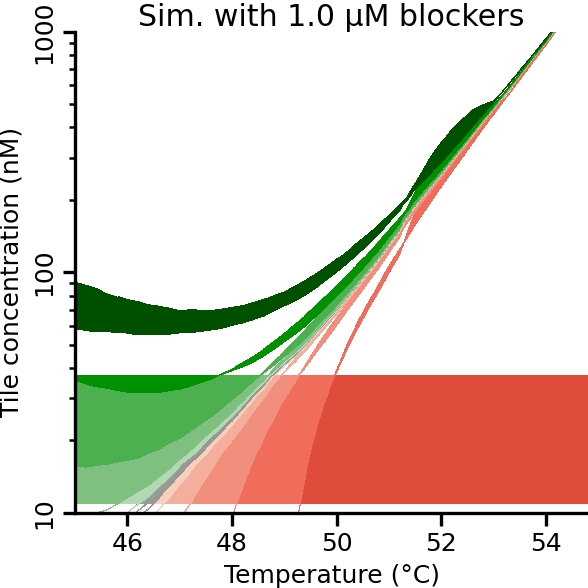

In [22]:
vals = v.filter(pl.col("blocker_conc").is_between(0.98e-6, 1.02e-6))

fig, ax = plt.subplots(figsize=(2, 2))

phase_diagram.draw_phase_diagram(vals, "temperature", "tile_conc", include_growth1_rates=False, ax=ax, 
    include_nucleation=False)

ax.set_title("Sim. with 1.0 µM blockers")

In [ ]:
xg = vals.pivot(index="temperature", on="tile_conc", values="temperature", aggregate_function="mean").select(pl.exclude("temperature"))
yg = vals.pivot(index="temperature", on="tile_conc", values="tile_conc", aggregate_function="mean").select(pl.exclude("temperature"))

growthrates_h = vals.pivot(index="temperature", on="tile_conc", values="growth_rate", aggregate_function="mean").select(pl.exclude("temperature"))









In [ ]:
g = vals.pivot(index="temperature", on="tile_conc", values="growth_rate", aggregate_function="mean")

In [ ]:
g

temperature,1.0985411419875584e-8,1.206792640639329e-8,1e-8,1.4563484775012439e-8,1.325711365590109e-8,1.5998587196060583e-8,1.7575106248547923e-8,1.9306977288832496e-8,2.1209508879201907e-8,2.329951810515372e-8,2.559547922699536e-8,2.811768697974231e-8,3.0888435964774816e-8,3.393221771895328e-8,5.42867543932386e-8,5.963623316594644e-8,4.941713361323834e-8,7.196856730011521e-8,7.906043210907697e-8,6.551285568595509e-8,8.685113737513526e-8,1.151395399326447e-7,4.4984326689694446e-8,1.0481131341546853e-7,9.540954763499939e-8,1.5264179671752336e-7,1.3894954943731376e-7,1.6768329368110066e-7,1.8420699693267165e-7,1.264855216855296e-7,2.2229964825261958e-7,3.9069399370546133e-7,2.44205309454865e-7,3.2374575428176437e-7,3.5564803062231287e-7,2.0235896477251556e-7,2.94705170255181e-7,2.6826957952797243e-7,4.2919342601287785e-7,7.543120063354616e-7,6.866488450042998e-7,8.286427728546843e-7,5.689866029018294e-7,6.25055192527397e-7,1.0000000000000002e-6,9.102981779915219e-7,5.179474679231214e-7,4.094915062380423e-8,4.71486636345739e-7,3.7275937203149396e-8
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
45.0,0.001397,0.001684,0.001093,0.002409,0.002092,0.002848,0.003318,0.003835,0.004398,0.004885,0.005662,0.006504,0.007256,0.008202,0.014871,0.016453,0.012991,0.020444,0.023489,0.018625,0.026089,0.037682,0.011783,0.032968,0.029351,0.054844,0.04858,0.062805,0.072202,0.04328,0.098583,0.272657,0.113981,0.189627,0.231534,0.082931,0.156572,0.132905,0.333048,0.99421,0.852758,1.207439,0.583129,0.713618,1.655684,1.45565,0.478364,0.010347,0.395781,0.009092
45.2,0.001297,0.001617,0.001001,0.002445,0.002032,0.002947,0.003409,0.003857,0.00448,0.005166,0.005821,0.006673,0.007621,0.008625,0.015496,0.017037,0.013639,0.02189,0.024345,0.019037,0.02711,0.039118,0.01224,0.03471,0.030631,0.057684,0.049594,0.066187,0.075547,0.04441,0.100999,0.276252,0.118246,0.193038,0.229961,0.086631,0.164064,0.137486,0.324472,1.010687,0.849469,1.208944,0.592575,0.68873,1.662113,1.41543,0.484428,0.010851,0.401323,0.009648
45.4,0.001219,0.001594,0.000874,0.002369,0.001962,0.002861,0.003304,0.003953,0.004624,0.005301,0.006108,0.006944,0.007815,0.008942,0.01601,0.018004,0.014202,0.022955,0.025804,0.019928,0.028191,0.041288,0.012994,0.036664,0.032761,0.059989,0.053,0.068082,0.079369,0.046095,0.10487,0.276818,0.121461,0.195866,0.233718,0.090336,0.164473,0.14311,0.329479,1.034395,0.844948,1.195981,0.599884,0.717869,1.689033,1.419865,0.478686,0.011364,0.407659,0.010118
45.6,0.001068,0.001508,0.000786,0.002318,0.001789,0.002813,0.003339,0.003979,0.004779,0.005499,0.006215,0.007056,0.007976,0.009149,0.016908,0.01892,0.015112,0.023476,0.027207,0.021195,0.03003,0.043,0.013175,0.038173,0.03345,0.062801,0.054668,0.071335,0.081441,0.048473,0.107752,0.279874,0.125122,0.19799,0.240803,0.092065,0.172207,0.144903,0.339121,1.008424,0.850274,1.22924,0.572735,0.679057,1.644472,1.4484,0.487197,0.011725,0.399771,0.010392
45.8,0.000878,0.001337,0.000549,0.002305,0.001727,0.002677,0.003275,0.003995,0.00463,0.005417,0.006405,0.007252,0.008188,0.009446,0.01728,0.019575,0.015652,0.024621,0.027594,0.021971,0.031292,0.045217,0.013898,0.039346,0.035348,0.065628,0.057174,0.073469,0.084049,0.050706,0.110523,0.283856,0.12816,0.20471,0.239539,0.096373,0.171819,0.149117,0.336308,1.011402,0.823957,1.197624,0.584785,0.701443,1.702309,1.41978,0.488994,0.012034,0.398365,0.010793
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
54.0,-6.798661,-6.677197,-6.646333,-6.506664,-6.637605,-6.495943,-6.659374,-6.278163,-6.660049,-6.357804,-6.375586,-6.165107,-6.212278,-5.855545,-5.756607,-5.486476,-5.887225,-5.102593,-5.138477,-5.545224,-4.814521,-4.473439,-5.823201,-4.592007,-4.686143,-3.651045,-3.992521,-3.526183,-3.039467,-4.247586,-2.457705,-0.709947,-2.173812,-1.021128,-0.877347,-2.604043,-1.43259,-1.95059,-0.525

ValueError: x and y arguments to pcolormesh cannot have non-finite values or be of type numpy.ma.MaskedArray with masked values

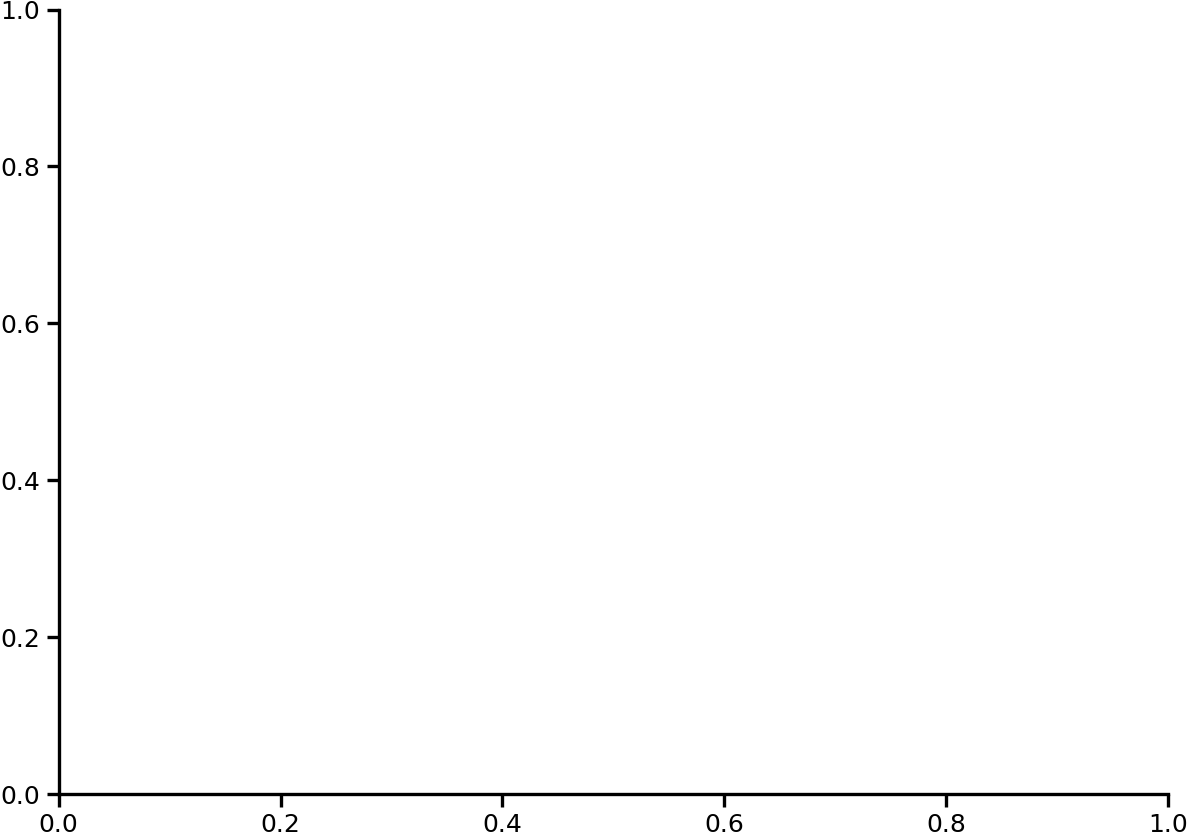

In [ ]:
plt.pcolormesh(xg, yg, growthrates_h)